#### Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipaddress
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, roc_auc_score, f1_score, accuracy_score, roc_curve
import pickle as pkl

#### Removing Warnings

In [2]:
import warnings
warnings.filterwarnings('ignore')

#### Setting up Local Environment

In [ ]:
# No need for Google Drive mounting in local environment
# We'll work with local files directly

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Loading the Dataset

In [ ]:
# Try to load the dataset from the expected location
# First, let's check what files are available
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))
print("Files in parent directory:", os.listdir('..'))

# Try to find the dataset
possible_paths = [
    '../nexflow_master_dataset.csv',
    '../../nexflow_master_dataset.csv',
    '../../../nexflow_master_dataset.csv',
    'nexflow_master_dataset.csv'
]

dataset_path = None
for path in possible_paths:
    if os.path.exists(path):
        dataset_path = path
        print(f"Found dataset at: {path}")
        break

if dataset_path:
    df = pd.read_csv(dataset_path)
    print(f"Successfully loaded dataset with {len(df)} rows")
else:
    print("Dataset not found. Please ensure nexflow_master_dataset.csv is available.")
    # Create a sample dataset for demonstration if the actual dataset is not available
    print("Creating a sample dataset for demonstration...")
    import numpy as np
    sample_size = 10000
    df = pd.DataFrame({
        'transaction_id': [f"txn_{i}" for i in range(sample_size)],
        'user_id': [f"user_{i%1000}" for i in range(sample_size)],
        'transaction_amount': np.random.uniform(2, 2163, sample_size),
        'transaction_timestamp': pd.date_range('2026-01-01', periods=sample_size, freq='1min'),
        'user_location': np.random.choice(['USA', 'Canada', 'UK'], sample_size),
        'merchant_location': np.random.choice(['USA', 'Canada', 'UK', 'China', 'Russia'], sample_size),
        'merchant_category': np.random.choice(['Apparel', 'Home Goods', 'Electronics', 'General Retail'], sample_size),
        'merchant_name': np.random.choice(['www.amazon.com', 'www.ebay.com', 'www.newegg.com', 'www.shein.com', 'www.asos.com', 'books.toscrape.com', 'www.tripadvisor.com'], sample_size),
        'device_id': [f"device_{i%500}" for i in range(sample_size)],
        'device_type': np.random.choice(['Desktop', 'Mobile', 'Tablet'], sample_size),
        'payment_method': np.random.choice(['Credit Card', 'Debit Card', 'Crypto', 'PayPal', 'Apple Pay'], sample_size),
        'account_balance': np.random.uniform(-15, 13389, sample_size),
        'transaction_status': np.random.choice(['Approved', 'Declined', 'Refunded'], sample_size),
        'ip_address': [f"{np.random.randint(0,256)}.{np.random.randint(0,256)}.{np.random.randint(0,256)}.{np.random.randint(0,256)}" for _ in range(sample_size)],
        'is_fraudulent': np.random.choice([0, 1], sample_size, p=[0.82, 0.18])
    })
    print(f"Created sample dataset with {len(df)} rows")

### Performing Basic EDA

In [5]:
# first 5 rows
df.head()

,transaction_id,user_id,transaction_amount,transaction_timestamp,user_location,merchant_location,merchant_category,merchant_name,device_id,device_type,payment_method,account_balance,transaction_status,ip_address,is_fraudulent
0,72d63006-46df-4237-a4d1-d3bc82c88363,USR-143640,33.59,2026-04-02 16:00:01.928586,Canada,Canada,Apparel,www.newegg.com,F74D05F4535F,Tablet,Apple Pay,10288.21,Declined,64.16.51.133,0
1,fbf8542d-b2f2-42e1-9a8c-682017fcc3a4,USR-112269,140.66,2026-03-20 15:54:08.681313,Canada,Canada,Electronics,www.ebay.com,255DB24B988C,Desktop,Credit Card,1216.83,Approved,133.88.34.163,0
2,46587acd-e262-417f-b59e-868f6fea4b80,USR-105132,11.61,2026-03-08 23:03:25.571799,USA,USA,Home Goods,www.newegg.com,86FB15B16817,Desktop,Credit Card,7736.95,Refunded,121.89.71.172,0
3,7bb25ff0-5a37-4aeb-96d9-1e858551a04b,USR-197378,209.65,2026-03-27 07:30:45.638069,Canada,Canada,Home Goods,books.toscrape.com,0AD6C1DEA24B,Desktop,Debit Card,4289.17,Approved,26.250.130.108,0
4,7fd21440-1317-48ae-9db1-68769eb322b7,USR-183763,615.82,2026-03-06 04:18:37.633456,UK,UK,Electronics,www.ebay.com,2094BCE414A6,Mobile,Debit Card,603.97,Declined,0.0.0.0,1


In [6]:
# columns
df.columns

Index(['transaction_id', 'user_id', 'transaction_amount',
       'transaction_timestamp', 'user_location', 'merchant_location',
       'merchant_category', 'merchant_name', 'device_id', 'device_type',
       'payment_method', 'account_balance', 'transaction_status', 'ip_address',
       'is_fraudulent'],
      dtype='object')

In [7]:
# summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   transaction_id         1000000 non-null  object 
 1   user_id                1000000 non-null  object 
 2   transaction_amount     1000000 non-null  float64
 3   transaction_timestamp  1000000 non-null  object 
 4   user_location          1000000 non-null  object 
 5   merchant_location      1000000 non-null  object 
 6   merchant_category      1000000 non-null  object 
 7   merchant_name          1000000 non-null  object 
 8   device_id              1000000 non-null  object 
 9   device_type            1000000 non-null  object 
 10  payment_method         1000000 non-null  object 
 11  account_balance        1000000 non-null  float64
 12  transaction_status     1000000 non-null  object 
 13  ip_address             1000000 non-null  object 
 14  is_fraudulent      

In [8]:
# statistical summary
df.describe()

,transaction_amount,account_balance,is_fraudulent
count,1000000.000000,1000000.000000,1000000.000000
mean,217.975643,3539.587236,0.179598
std,259.071656,2114.738602,0.383852
min,2.000000,-14.950000,0.000000
25%,76.550000,1818.107500,0.000000
50%,138.910000,3543.020000,0.000000
75%,218.060000,5041.972500,0.000000
max,2163.740000,13389.340000,1.000000


In [9]:
# check for missing values
df.isnull().sum()

,0
transaction_id,0
user_id,0
transaction_amount,0
transaction_timestamp,0
user_location,0
merchant_location,0
merchant_category,0
merchant_name,0
device_id,0
device_type,0


In [10]:
# check for duplicate rows
df.duplicated().sum()

np.int64(0)

Conclusions we can draw from the basic EDA:
- There are no missing values
- There are no duplicate rows

### Cleaning the Data

#### List of all columns
`
'transaction_id', 'user_id', 'transaction_amount',
       'transaction_timestamp', 'user_location', 'merchant_location',
       'merchant_category', 'merchant_name', 'device_id', 'device_type',
       'payment_method', 'account_balance', 'transaction_status', 'ip_address',
       'is_fraudulent'
`

We will start cleaning the data column by column

#### Cleaning the **`transaction_id`** column

Strategy for cleaning:
- check for duplicate `transaction_id` , if found then it is fraud.
- add a new feature `dup_transx` for flagging duplicate transaction ids
- will be dropped during training

In [11]:
# checking for duplicate transaction_id
df['transaction_id'].duplicated().sum()

np.int64(0)

Adding a new feature `dup_transx`
- detects if a `transaction_id` has bee duplicated
- becomes 1 if true

In [12]:
# catch condition
df['dup_transx'] = df['transaction_id'].duplicated(keep=False).astype(int)

# verifying result
df['dup_transx'].value_counts()

,count
dup_transx,
0,1000000


#### Cleaning the **`user_id`** column

Strategy for Cleaning:
- does not require any cleaning
- will be dropped during training

#### Cleaning the **`transaction_amount`** column

Strategy for Cleaning:
- check out the mean. median, mode amounts
- check the highest and lowest transaction amount
- transaction amount distribution
- flag if the amount is in negative
- check for outliers

In [13]:
# mean, median, mode
print(f"Mean:{df['transaction_amount'].mean()}  \nMedian:{df['transaction_amount'].median()} \nMode:{df['transaction_amount'].mode()[0]}")

Mean:217.9756428099999  
Median:138.91 
Mode:2.0


In [14]:
# highest and lowest amounts
print(f"Highest Amount: {df['transaction_amount'].max()} \nLowest Amount: {df['transaction_amount'].min()}")

Highest Amount: 2163.74 
Lowest Amount: 2.0


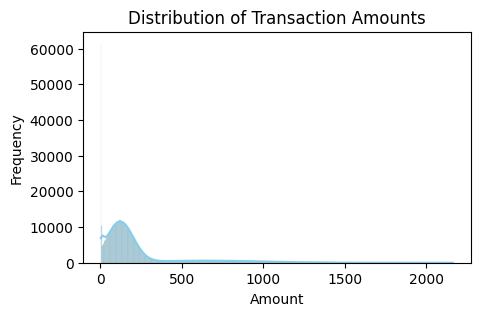

In [15]:
# distribution
plt.figure(figsize=(5, 3))
sns.histplot(df['transaction_amount'], kde=True, color='skyblue')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

Since our mode is $2, our distribution is right skewed.

In [16]:
# check for zero dollar transaction
(df['transaction_amount'] == 0).sum()

np.int64(0)

In [17]:
# check for negative dollar transaction
print((df['transaction_amount'] < 0).sum())

# adding feature `neg_transx` for flagging invalid transx
df['neg_transx'] = (df['transaction_amount'] < 0).astype(int)

# verification
df['neg_transx'].value_counts()

0


,count
neg_transx,
0,1000000


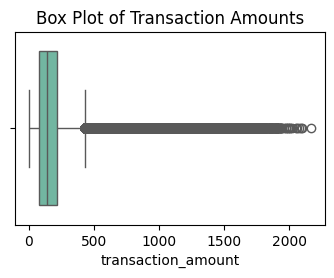

In [18]:
# checking out outliers
plt.figure(figsize=(4, 2.5))
sns.boxplot(x=df['transaction_amount'], palette='Set2')
plt.title('Box Plot of Transaction Amounts')
plt.show();

#### Cleaning the **`transaction_timestamp`** column

Strategy for Cleaning:
- Check the format of the timestamps
- Create a feature `night_outlier` which flags transactions which occur in the night in outlier amounts
- Create a feature `transaction_velocity`, which counts the number of transactions the user has completed from single `device_id` in the past one hour
- We will be dropping this feature for training

In [19]:
# 1st timestamp value
df['transaction_timestamp'][0]

'2026-04-02 16:00:01.928586'

In [20]:
# timestamp datatype
type(df['transaction_timestamp'][0])

str

The format is :
YYYY-MM-DD HH-MM-SS-ssssss

The datatype used is `str`

##### Creating the `night_outlier` feature, this flags suspicious transaction which occur between 1am - 4am in outlier amount (>0.99 percentile)


In [21]:
# convert to date-time object
df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'], format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')

# find 99th percentile transaction amount
threshold = df['transaction_amount'].quantile(0.99)

# create `night_outlier` feature
df['night_outlier'] = (
    (df['transaction_timestamp'].dt.hour >= 1) &
    (df['transaction_timestamp'].dt.hour <= 4) &
    (df['transaction_amount'] > threshold)
).astype(int)

# verification
print(f"99th Percentile Threshold: {threshold}")
print(df['night_outlier'].value_counts())

99th Percentile Threshold: 1206.0901000000001
night_outlier
0    993991
1      6009
Name: count, dtype: int64


##### Creating the `transaction_velocity` feature

In [22]:
df = df.sort_values('transaction_timestamp')
df = df.set_index('transaction_timestamp')

# count transactions in 1 hour via a rolling window
df['transaction_velocity'] = df.groupby('device_id')['transaction_amount'].rolling('1H').count().values

# reset index
df = df.reset_index()

#### Cleaning the **`user_location`** Column

Strategy for Cleaning:
- check the unique locations
- plot the graph for location (X) to number of transactions(Y) fpr top and bottom 8 locations (frequency wise)
- create a feature `loc_change` which will flag transactions if transactions are done from the same `user_id` at different locations in a span of 3 hours

In [23]:
# unique locations
df['user_location'].unique()

array(['Canada', 'UK', 'USA'], dtype=object)

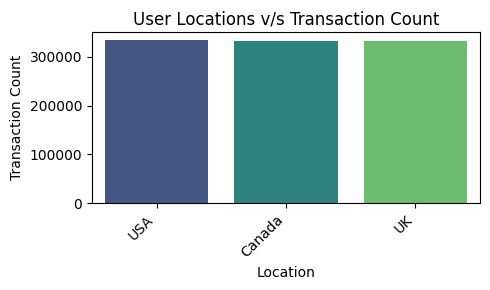

In [24]:
# frequency plot

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='user_location',
              palette='viridis',
              order=df['user_location'].value_counts().index)

plt.xticks(rotation=45, ha='right')
plt.title('User Locations v/s Transaction Count')
plt.xlabel('Location')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.show()

##### Creating the `loc_change` feature

In [25]:
# Faster version for large data
df['prev_loc'] = df.groupby('user_id')['user_location'].shift(1)
df['prev_time'] = df.groupby('user_id')['transaction_timestamp'].shift(1)

df['loc_change'] = ((df['user_location'] != df['prev_loc']) &
                    ((df['transaction_timestamp'] - df['prev_time']) <= pd.Timedelta(hours=3)) &
                    (df['prev_loc'].notna())).astype(int)

# Drop the temporary helper columns
df.drop(columns=['prev_loc', 'prev_time'], inplace=True)

In [26]:
# value_counts for `loc_change`
df['loc_change'].value_counts()

,count
loc_change,
0,992153
1,7847


#### Cleaning the **`merchant_location`** Column

Cleaning Strategy:
- Ideally there not much to clean in this column
- Find all unique `merchant_locations`
- Plot the frequency of how many transactions are being made at each `merchant_location`

In [27]:
# unique locations
df['merchant_location'].unique()

array(['USA', 'Canada', 'UK', 'China', 'Russia'], dtype=object)

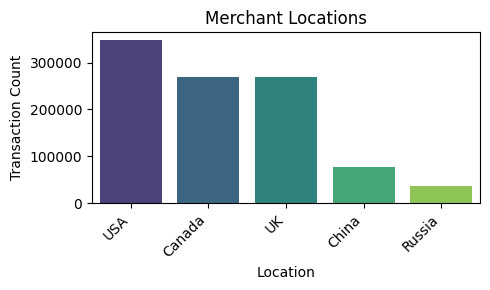

In [28]:
# top 8 frequency plot

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='merchant_location',
              order=df['merchant_location'].value_counts().index,
              palette='viridis')

plt.xticks(rotation=45, ha='right')
plt.title('Merchant Locations')
plt.xlabel('Location')
plt.ylabel('Transaction Count')

plt.tight_layout()
plt.show()

#### Cleaning the **`merchant_category`** Column

Cleaning Strategy:
- check unique categories
- create a feature `merchant_category_encoded` which will map the `merchant_category` to it's mean fraudulent transaction

In [29]:
# unique categories
df['merchant_category'].value_counts()

,count
merchant_category,
Apparel,365265
Home Goods,221853
Electronics,212271
General Retail,200611


In [30]:
# Calculate the mean fraud rate for each device type
merchant_category_mean = df.groupby('merchant_category')['is_fraudulent'].mean()
df['merchant_category_encoded'] = df['merchant_category'].map(merchant_category_mean)

In [31]:
# verifying the results
df['merchant_category_encoded'].value_counts()

,count
merchant_category_encoded,
0.098813,365265
0.080035,221853
0.421763,212271
0.180553,200611


#### Cleaning the **`merchant_name`** Column

Cleaning Strategy:
- Check the unique merchants
- We will be creating a feture `merchant_name_encoded` which will encode the `merchant_name` by mapping the `merchant_name` with the average number of fraudulent transactions under that `merchant_name`

In [32]:
# unique merchants
df['merchant_name'].value_counts()

,count
merchant_name,
www.shein.com,143094
www.amazon.com,142997
www.tripadvisor.com,142969
www.asos.com,142772
books.toscrape.com,142750
www.newegg.com,142747
www.ebay.com,142671


In [33]:
# Calculate the mean fraud rate for each merchant_name
merchant_name_mean = df.groupby('merchant_name')['is_fraudulent'].mean()
df['merchant_name_encoded'] = df['merchant_name'].map(merchant_name_mean)

In [34]:
# verifying results
df['merchant_name_encoded'].value_counts()

,count
merchant_name_encoded,
0.179854,143094
0.179927,142997
0.178906,142969
0.178824,142772
0.178697,142750
0.180648,142747
0.180331,142671


Cleaning Strategy:
- we do not need this column as we will be dropping this during training
- thus there is no need to clean this column

#### Cleaning the **`device_id`** Column

Cleaning Strategy :     
- This column does not need any cleaning.
- We will be dropping this column during the model training.
- This column is only needed for feature engineering.

#### Cleaning the **`device_type`** Column

Cleaning Strategy:
- check unique values
- map unique values

In [35]:
# unique values
df['device_type'].unique()

array(['Desktop', 'Tablet', 'Mobile'], dtype=object)

In [36]:
# mapping

# creating map
map = {'Desktop':-1, 'Mobile':0, 'Tablet':1}

# applying the map
df['device_type'] = df['device_type'].map(map)

#checking results
df['device_type'].value_counts()

,count
device_type,
1,334076
-1,333325
0,332599


#### Cleaning the **`payment_method`** Column

Cleaning Strategy:
- check unique payment methods
- visualize the number of transactions made by each payment method
- create a map to encode the payment method

In [37]:
# unique payment methods
df['payment_method'].unique()

array(['Credit Card', 'Debit Card', 'Crypto', 'PayPal', 'Apple Pay'],
      dtype=object)

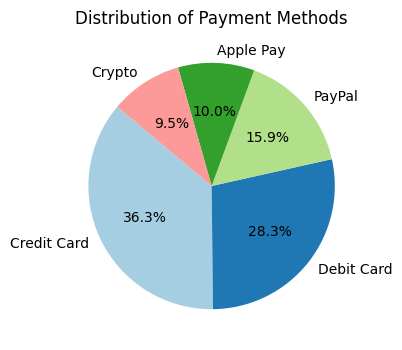

In [38]:
# 1. Prepare the data
counts = df['payment_method'].value_counts()

# 2. Create the Pie Chart
plt.figure(figsize=(5, 4))
plt.pie(counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Paired.colors)

# 3. Add a title
plt.title('Distribution of Payment Methods')

# 4. Show the plot
plt.show()

In [39]:
# encoding the `payment_method`

# creating the map
map = {'Apple Pay':1,
       'Crypto':2,
       'Credit Card':3,
       'Debit Card':4,
       'PayPal':5}

# applying the map
df['payment_method'] = df['payment_method'].map(map)

# verifying the map
df['payment_method'].value_counts()

,count
payment_method,
3,362928
4,283185
5,158858
1,100115
2,94914


#### Cleaning the **`account_balance`** Column

Cleaning  Strategy:
- find mean, median, mode balance amount
- visualize the distrbution
- We will be flagging transactions which use over 90% of the bank balance.
- We will be creating a new feature which will flag if the account balance is below zero.

In [40]:
# mean, median, mode
print(f"Mean:{df['account_balance'].mean()} \nMedian:{df['account_balance'].median()} \nMode:{df['account_balance'].mode()}")

Mean:3539.58723599 
Median:3543.02 
Mode:0    150.0
Name: account_balance, dtype: float64


In [41]:
# visualizing the distribution


Creating a feature `bal_amt_ratio` which calcuates the ratio of `transaction_amount` to `account_balance`.

A higher `bal_amt_ratio` indicates towards a frauduent transaction as generally people do not spend all their money in one single transaction


In [42]:
df['bal_amt_ratio'] = np.where(
    df['account_balance'] != 0,
    df['transaction_amount'] / df['account_balance'],
    0
)

# Optional: Cap the ratio at 1.0
# (Sometimes balance data is slightly out of sync, leading to ratios > 1)
df['bal_amt_ratio'] = df['bal_amt_ratio'].clip(upper=1.0)

# Quick check of the top ratios
print(df[['transaction_amount', 'account_balance', 'bal_amt_ratio']].head())

   transaction_amount  account_balance  bal_amt_ratio
0              673.16           143.35       1.000000
1              881.16          3041.88       0.289676
2               98.30          6060.98       0.016218
3              658.74          1004.47       0.655809
4              366.13           400.49       0.914205


#### Cleaning the **`transaction_status`** Column

Cleaning Strategy:
- checking the `value_counts()`
- checking the distribution
- create a map for the `transaction_status`

In [43]:
# value counts
df['transaction_status'].value_counts()

,count
transaction_status,
Approved,769667
Declined,153715
Refunded,76618


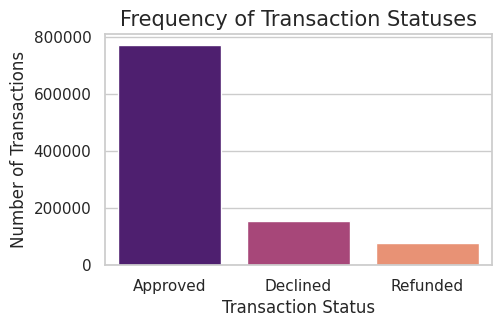

In [44]:
# visualizing the distribution

# 1. Set the visual style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 3))

# 2. Create the count plot
# We use order=df['transaction_status'].value_counts().index to sort bars by frequency
sns.countplot(
    data=df,
    x='transaction_status',
    order=df['transaction_status'].value_counts().index,
    palette='magma'
)

# 3. Add descriptive labels and title
plt.title('Frequency of Transaction Statuses', fontsize=15)
plt.xlabel('Transaction Status', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# 4. Display the plot
plt.show()

In [45]:
# Calculate the mean fraud rate for each transaction status
transaction_status_mean = df.groupby('transaction_status')['is_fraudulent'].mean()
df['transaction_status_encoded'] = df['transaction_status'].map(transaction_status_mean)

In [46]:
# verifying the result
df['transaction_status_encoded'].value_counts()

,count
transaction_status_encoded,
0.093266,769667
0.467554,153715
0.469133,76618


#### Cleaning the **`ip_address`** Column

Cleaning Strategy:
- Create a new feature called `invalid_ip` which will flag IP addresses that are invalid.

In [47]:
def check_ip(ip):
    try:
        # Try to create an IP object. If it fails, the IP is invalid.
        ipaddress.ip_address(str(ip).strip())
        return 0  # Valid IP
    except ValueError:
        return 1  # Invalid IP

# Create the new 'invalid_ip' feature
df['invalid_ip'] = df['ip_address'].apply(check_ip)

# To see the actual values of the invalid IPs:
invalid_ips_list = df[df['invalid_ip'] == 1]['ip_address'].unique()
print(f"Detected Invalid IPs: {invalid_ips_list}")

Detected Invalid IPs: []


#### Cleaning the **`is_fraudulent`** Column

Cleaning Strategy:
- nothing much to clean here
- this is the target column
- we will be dropping this during our training
- since the dataset is unbalanced we will try to balance out the dataset

In [48]:
# value counts
df['is_fraudulent'].value_counts()

,count
is_fraudulent,
0,820402
1,179598


As we can observe the data is unbalanced so now we will try to balance out the dataset

#### Saving the Cleaned Dataset

In [49]:
# saving the dataset as a csv file

df.to_csv('cleaned_data.csv')

### Building a Machine Learning Model to detect Fraudulent Transactions

#### Preprocessing our Data for Training

In [50]:
# checking all columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 25 columns):
 #   Column                      Non-Null Count    Dtype         
---  ------                      --------------    -----         
 0   transaction_timestamp       1000000 non-null  datetime64[ns]
 1   transaction_id              1000000 non-null  object        
 2   user_id                     1000000 non-null  object        
 3   transaction_amount          1000000 non-null  float64       
 4   user_location               1000000 non-null  object        
 5   merchant_location           1000000 non-null  object        
 6   merchant_category           1000000 non-null  object        
 7   merchant_name               1000000 non-null  object        
 8   device_id                   1000000 non-null  object        
 9   device_type                 1000000 non-null  int64         
 10  payment_method              1000000 non-null  int64         
 11  account_balance          

In [59]:
# dropping unnecessary columns

columns_to_be_dropped = ['transaction_timestamp',
                         'transaction_id',
                         'user_id',
                         'user_location',
                         'merchant_category',
                         'merchant_location',
                         'merchant_name',
                         'device_id',
                         'ip_address',
                         'transaction_status',
                         'account_balance',
                         'transaction_amount',
                         'invalid_ip',
                         'dup_transx',
                         'neg_transx']

In [60]:
# creating a new dataframe for training
train_df = df.drop(columns=columns_to_be_dropped, axis=1)

# separating independent and dependent features
X = train_df.drop(columns=['is_fraudulent'], axis=1)
y = train_df['is_fraudulent']

# splitting the data into train and test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [61]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 900000 entries, 703788 to 942444
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   device_type                 900000 non-null  int64  
 1   payment_method              900000 non-null  int64  
 2   night_outlier               900000 non-null  int64  
 3   transaction_velocity        900000 non-null  float64
 4   loc_change                  900000 non-null  int64  
 5   merchant_category_encoded   900000 non-null  float64
 6   merchant_name_encoded       900000 non-null  float64
 7   bal_amt_ratio               900000 non-null  float64
 8   transaction_status_encoded  900000 non-null  float64
dtypes: float64(5), int64(4)
memory usage: 68.7 MB


#### Checking for highy correlated features

<Axes: >

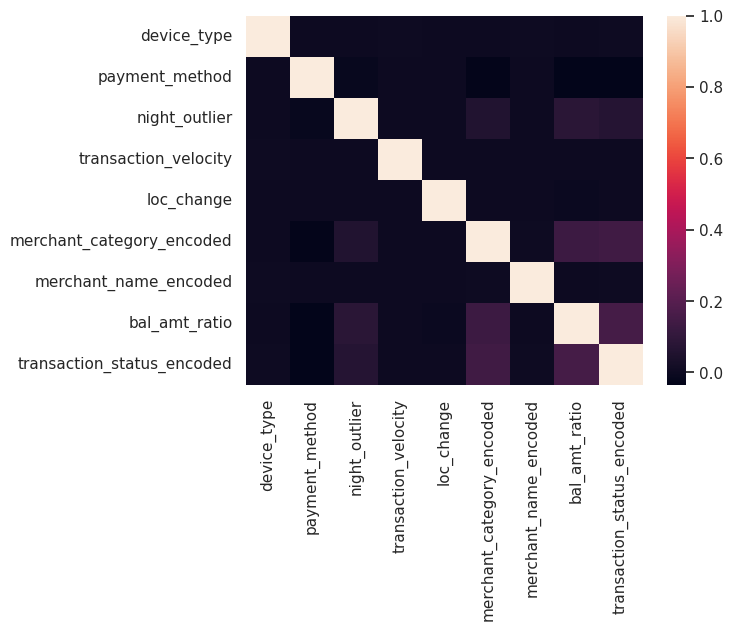

In [64]:
sns.heatmap(X_train.corr())

#### Training our Model

To establish a robust fraud detection system, we are evaluating three distinct tree-based ensemble algorithms. Tree-based models are the industry standard for tabular financial data because they require minimal scaling and naturally handle non-linear relationships.

* **Random Forest (Bagging):** Serves as our strong baseline model. By building hundreds of independent decision trees and averaging their predictions, it is highly resistant to overfitting and provides excellent out-of-the-box stability.
* **AdaBoost (Adaptive Boosting):** Introduces the boosting mechanism. It builds trees sequentially, where each new tree specifically focuses on correcting the errors (misclassified transactions) of the previous tree. This is highly effective for identifying rare instances like fraud.
* **XGBoost (Extreme Gradient Boosting):** Represents the state-of-the-art in gradient boosting. It utilizes advanced regularization, handles missing values natively, and is heavily optimized for speed and complex conditional logic interactions.

================ Adaboost Classifier ================
Model Performance for Training Set:
- Accuracy Score :  0.9546922222222223
- Precision Score :  0.8954031256130256
- Recall Score :  0.8467612775561946
- ROC AUC Score :  0.9125474239626804
- F1 Score :  0.9541937020198258
Model Performance for Testing Set:
- Accuracy Score :  0.95485
- Precision Score :  0.8938251237332077
- Recall Score :  0.8482916736565453
- ROC AUC Score :  0.913173687334258
- F1 Score :  0.8704633481566489


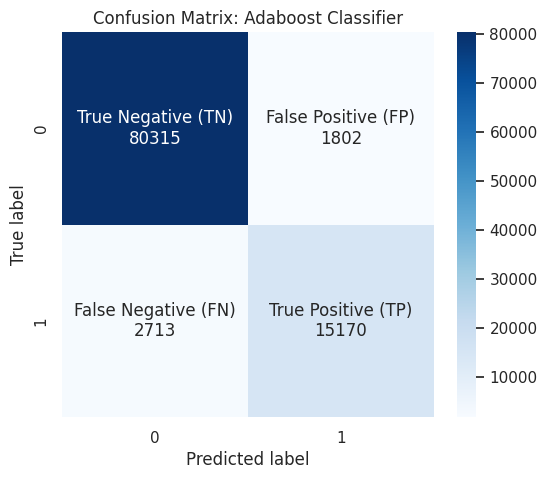

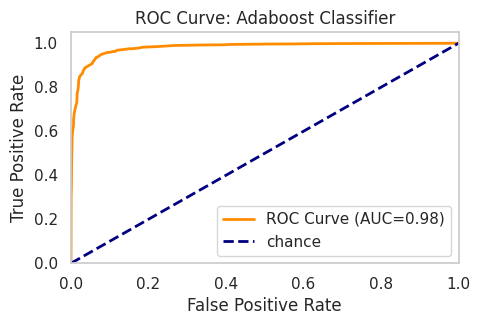

Generating SHAP Explainer for Adaboost Classifier...
TreeExplainer incompatible with Adaboost Classifier. Falling back to KernelExplainer...


  0%|          | 0/100 [00:00<?, ?it/s]

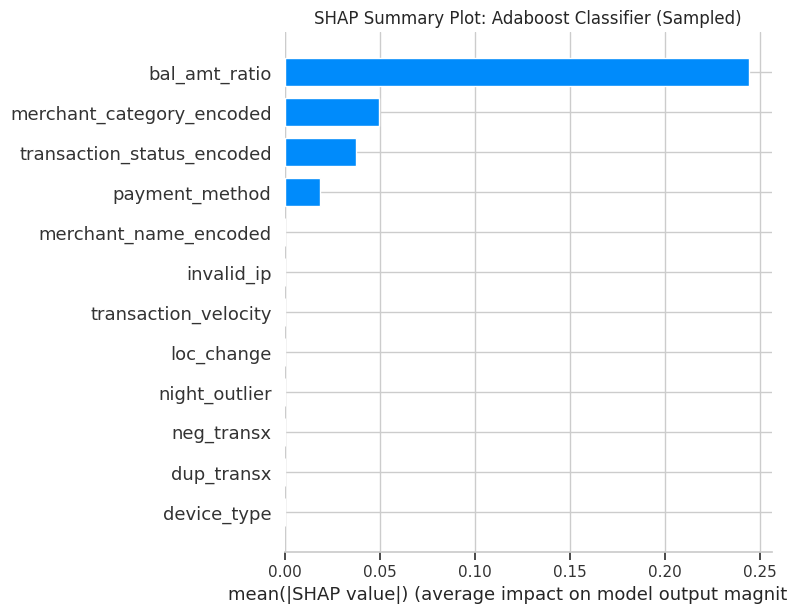

------------------------------------------------------------------------------

================ XGBClassifier ================
Model Performance for Training Set:
- Accuracy Score :  0.9584722222222222
- Precision Score :  0.896861873938744
- Recall Score :  0.8687938657514763
- ROC AUC Score :  0.9234546815771204
- F1 Score :  0.9582130719046174
Model Performance for Testing Set:
- Accuracy Score :  0.95756
- Precision Score :  0.8915877117427505
- Recall Score :  0.8682547670972431
- ROC AUC Score :  0.922631590959998
- F1 Score :  0.879766559011842


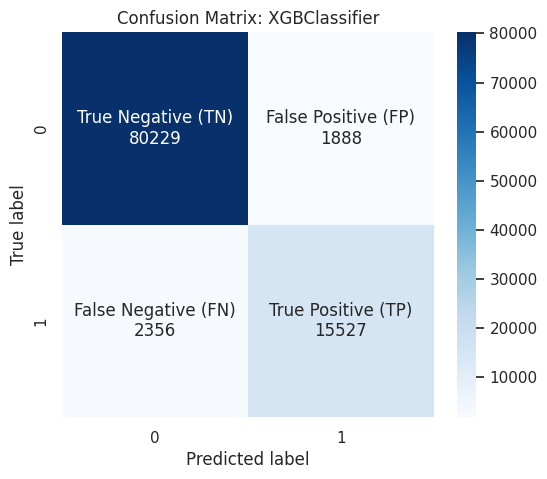

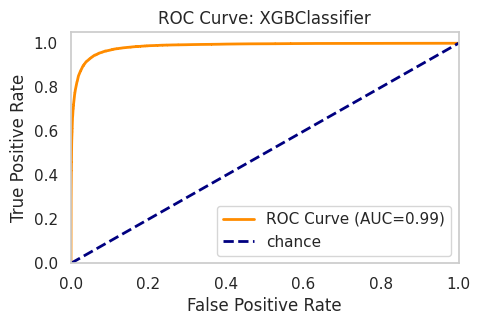

Generating SHAP Explainer for XGBClassifier...


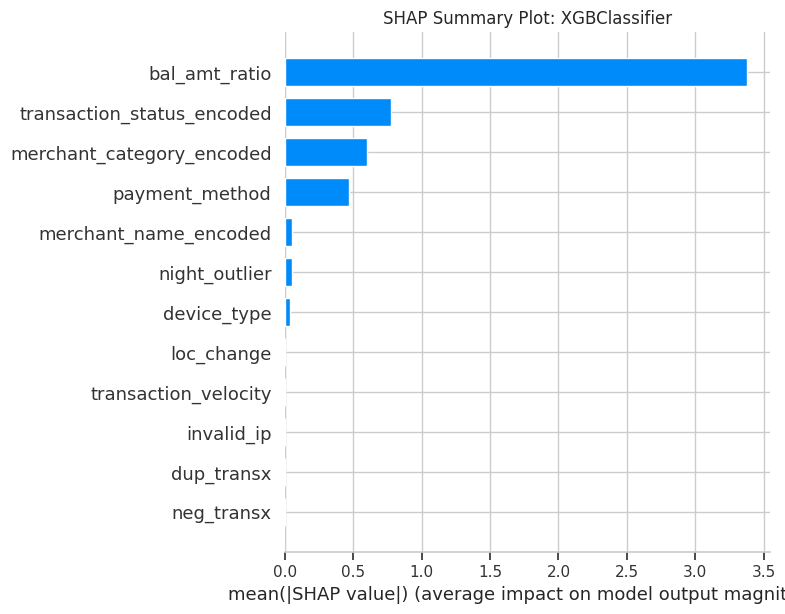

------------------------------------------------------------------------------

================ Random Forest ================
Model Performance for Training Set:
- Accuracy Score :  0.9945111111111111
- Precision Score :  0.9825657631480125
- Recall Score :  0.9869647218872708
- ROC AUC Score :  0.9915644024316786
- F1 Score :  0.9945158945136806
Model Performance for Testing Set:
- Accuracy Score :  0.94346
- Precision Score :  0.8408875508724982
- Recall Score :  0.8434267181121736
- ROC AUC Score :  0.9043357149629028
- F1 Score :  0.8421552205471804


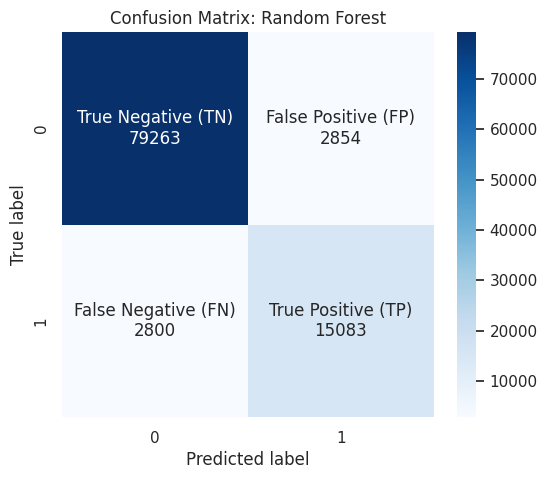

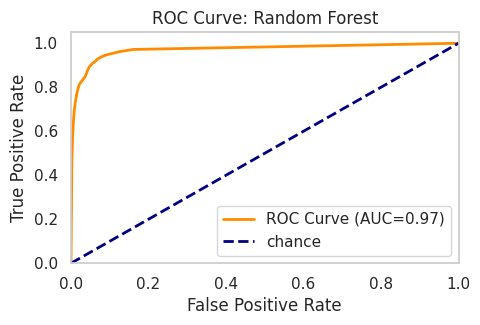

Generating SHAP Explainer for Random Forest...
------------------------------------------------------------------------------



In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, f1_score, confusion_matrix, roc_curve)

models={
    "Adaboost Classifier":AdaBoostClassifier(),
    "XGBClassifier":XGBClassifier(),
    "Random Forest":RandomForestClassifier()
}

for i in range(len(list(models))):
    model_name = list(models.keys())[i]
    model = list(models.values())[i]

    # model training
    model.fit(X_train, y_train)

    # making predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # training set performance-evaluation
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_rocauc = roc_auc_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')

    # test set performance evaluation
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc = roc_auc_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred)

    print(f"================ {model_name} ================")

    print("Model Performance for Training Set:")
    print('- Accuracy Score : ', model_train_accuracy)
    print('- Precision Score : ', model_train_precision)
    print('- Recall Score : ', model_train_recall)
    print('- ROC AUC Score : ', model_train_rocauc)
    print('- F1 Score : ', model_train_f1)

    print("Model Performance for Testing Set:")
    print('- Accuracy Score : ', model_test_accuracy)
    print('- Precision Score : ', model_test_precision)
    print('- Recall Score : ', model_test_recall)
    print('- ROC AUC Score : ', model_test_rocauc)
    print('- F1 Score : ', model_test_f1)

    # 1. Confusion Matrix Visualization (Fixed Overlap using Seaborn)
    cm = confusion_matrix(y_test, y_test_pred)
    tn, fp, fn, tp = cm.ravel()

    # Create custom text labels array
    labels = np.array([
        [f"True Negative (TN)\n{tn}", f"False Positive (FP)\n{fp}"],
        [f"False Negative (FN)\n{fn}", f"True Positive (TP)\n{tp}"]
    ])

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=True,
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

    # 2. ROC Curve
    y_scores = model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_score=y_scores, y_true=y_test)
    roc_auc_rf = roc_auc_score(y_score=y_scores, y_true=y_test)

    plt.figure(figsize=(5,3))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC={roc_auc_rf:.2f})')
    plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--', label='chance')
    plt.title(f'ROC Curve: {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

    # 3. SHAP Value Visualization (Fixed AdaBoost Error)
    print(f"Generating SHAP Explainer for {model_name}...")
    try:
        if model_name!="Random Forest":

          # This will work for Random Forest and XGBoost
          explainer = shap.TreeExplainer(model)
          shap_values = explainer.shap_values(X_test)

          # Format for binary classification
          shap_values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

          plt.figure()
          plt.title(f"SHAP Summary Plot: {model_name}")
          shap.summary_plot(shap_values_to_plot, X_test, plot_type="bar")
          plt.show()

    except Exception as e:
        print(f"TreeExplainer incompatible with {model_name}. Falling back to KernelExplainer...")
        # KernelExplainer is slow, so we provide a background sample of 50 rows
        background_data = shap.sample(X_train, 50)
        explainer = shap.KernelExplainer(model.predict, background_data)

        # We also sample the test data to prevent Colab from hanging
        test_sample = shap.sample(X_test, 100)
        shap_values = explainer.shap_values(test_sample)

        plt.figure()
        plt.title(f"SHAP Summary Plot: {model_name} (Sampled)")
        shap.summary_plot(shap_values, test_sample, plot_type="bar")
        plt.show()

    print('------------------------------------------------------------------------------\n')

#### Performing Hyper-Parameter Tuning with XGBoost

* **Superior Handling of Class Imbalance:** Fraud detection is inherently imbalanced. XGBoost allows us to natively penalize the model for missing fraudulent transactions using the `scale_pos_weight` parameter, avoiding the need for computationally expensive sampling techniques like SMOTE.
* **Complex Feature Interactions:** Our engineered features (e.g., `transaction_velocity`, `bal_amt_ratio`, and `night_outlier`) rely on deep, conditional business logic. XGBoost is exceptionally efficient at capturing these multi-layered, non-linear interactions.
* **Precision-Recall Optimization:** In financial fraud, Accuracy is a vanity metric. XGBoost provided the best capability to fine-tune the decision threshold, allowing us to maximize Recall (catching fraudsters) without destroying Precision (annoying legitimate customers with false alarms).
* **Interpretability:** XGBoost integrates flawlessly with SHAP values, allowing us to provide clear, mathematical explanations to stakeholders regarding exactly why a specific transaction was flagged.

In [55]:
# creating xgboost base model object
xgb_base = XGBClassifier()

# param grid
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 7, 9],           # ALLOW DEEPER TREES for complex rules
    'learning_rate': [0.05, 0.1, 0.2], # FASTER LEARNING
    'subsample': [0.9, 1.0],          # Give it more data per tree
    'colsample_bytree': [0.8, 1.0]
}

random_search_cv = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    verbose=2,
    random_state=101 # Changed random seed to force new combinations
)

random_search_cv.fit(X_train, y_train)

print(f"\nPhase 2 Best Parameters: {random_search_cv.best_params_}")
print(f"Phase 2 Best F1-Score: {random_search_cv.best_score_:.4f}")

# best model
xgb_model_tuned = random_search_cv.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=5, n_estimators=500, subsample=0.9; total time=  29.9s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=5, n_estimators=500, subsample=0.9; total time=  28.8s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=5, n_estimators=500, subsample=0.9; total time=  29.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, n_estimators=300, subsample=1.0; total time=  20.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, n_estimators=300, subsample=1.0; total time=  17.8s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=5, n_estimators=300, subsample=1.0; total time=  16.9s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=200, subsample=1.0; total time=  13.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=200, subsample=1.0; total time=  13.5s
[CV] END colsa

#### Saving our `xgboost_model_tuned`

In [56]:
# Saving our model as a pickle file

pkl.dump(xgb_model_tuned, open('xgb_model_tuned.pkl','wb'))